# 02. Multiple Linear Regression

데이터의 값중 범주형 데이터가 있음 이러한 데이터를 One-Hot encoding을 해주는데 이때 생기는 오류

다중공선성(Multicollinearity): 독립변수들 간에 서로 강한 상관관계를 가지면서 회귀계수 추정의 오류가 나타나는 문제

one-hot encoding
내가 표시할 값은 1 나머지값은 0
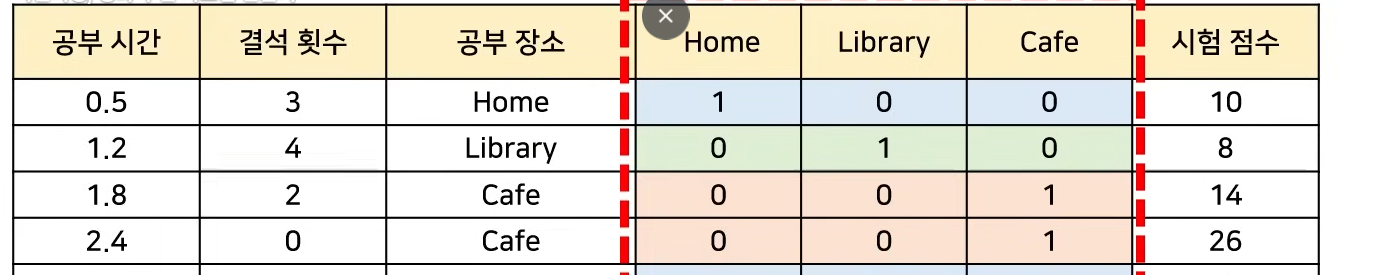


해결방법은 Dummy Column이 n개면 n-1개만 사용한다. -> Dummy variable trap

In [1]:
import pandas as pd

In [9]:
dataSet = pd.read_csv('MultipleLinearRegressionData.csv')
X = dataSet.iloc[:,:-1].values
y = dataSet.iloc[:,-1].values
X

array([[0.5, 3, 'Home'],
       [1.2, 4, 'Library'],
       [1.8, 2, 'Cafe'],
       [2.4, 0, 'Cafe'],
       [2.6, 2, 'Home'],
       [3.2, 0, 'Home'],
       [3.9, 0, 'Library'],
       [4.4, 0, 'Library'],
       [4.5, 5, 'Home'],
       [5.0, 1, 'Cafe'],
       [5.3, 2, 'Cafe'],
       [5.8, 0, 'Cafe'],
       [6.0, 3, 'Library'],
       [6.1, 1, 'Cafe'],
       [6.2, 1, 'Library'],
       [6.9, 4, 'Home'],
       [7.2, 2, 'Cafe'],
       [8.4, 1, 'Home'],
       [8.6, 1, 'Library'],
       [10.0, 0, 'Library']], dtype=object)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'), [2])], remainder='passthrough')
X = ct.fit_transform(X)
X

# 1 0 = Home
# 0 1 = Library
# 0 0 = Cafe

array([[1.0, 0.0, 0.5, 3],
       [0.0, 1.0, 1.2, 4],
       [0.0, 0.0, 1.8, 2],
       [0.0, 0.0, 2.4, 0],
       [1.0, 0.0, 2.6, 2],
       [1.0, 0.0, 3.2, 0],
       [0.0, 1.0, 3.9, 0],
       [0.0, 1.0, 4.4, 0],
       [1.0, 0.0, 4.5, 5],
       [0.0, 0.0, 5.0, 1],
       [0.0, 0.0, 5.3, 2],
       [0.0, 0.0, 5.8, 0],
       [0.0, 1.0, 6.0, 3],
       [0.0, 0.0, 6.1, 1],
       [0.0, 1.0, 6.2, 1],
       [1.0, 0.0, 6.9, 4],
       [0.0, 0.0, 7.2, 2],
       [1.0, 0.0, 8.4, 1],
       [0.0, 1.0, 8.6, 1],
       [0.0, 1.0, 10.0, 0]], dtype=object)

### 데이터 세트 분리

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

### 학습(다중 선형 회귀)

In [14]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = reg.predict(X_test)
y_pred

array([ 92.15457859,  10.23753043, 108.36245302,  38.14675204])

In [16]:
y_test

array([ 90,   8, 100,  38], dtype=int64)

In [18]:
reg.coef_

array([-5.82712824, -1.04450647, 10.40419528, -1.64200104])

In [19]:
reg.intercept_

5.365006706544804

### 모델 평가

In [20]:
reg.score(X_train,y_train) #훈련세트

0.9623352565265527

In [21]:
reg.score(X_test, y_test) #테스트세트

0.9859956178877447

y= b + m_1x_1 + m_2x_2 + m_3x_3